# 🧹 Telco Customer Churn — Data Cleaning

**Dataset:** `WA_Fn-UseC_-Telco-Customer-Churn.csv`  
**Goal:** Clean and prepare the raw dataset for EDA and modelling.

### 🗂️ Cleaning Steps
1. Load & inspect raw data
2. Fix `TotalCharges` — convert from object → float (11 whitespace entries)
3. Handle missing values created after type conversion
4. Convert `SeniorCitizen` from int (0/1) → readable Yes/No
5. Simplify multi-value columns (`No phone service`, `No internet service` → `No`)
6. Convert `Churn` to binary int (0/1) for modelling
7. Standardise column names (snake_case)
8. Remove duplicates (sanity check)
9. Validate & export cleaned data

## 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2️⃣ Load Raw Data

In [2]:
RAW_PATH = '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(RAW_PATH)

print(f'📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

📊 Shape: 7,043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3️⃣ Initial Inspection

In [3]:
print('🔍 Data Types & Non-Null Counts')
print('=' * 45)
df.info()

🔍 Data Types & Non-Null Counts
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBi

In [4]:
print('📈 Numerical Summary')
df.describe()

📈 Numerical Summary


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [5]:
print('🔎 Null / Missing Values per Column')
print('=' * 45)
null_summary = pd.DataFrame({
    'Null Count'  : df.isnull().sum(),
    'Null %'      : (df.isnull().sum() / len(df) * 100).round(2),
    'Dtype'       : df.dtypes
})
if null_summary['Null Count'].sum() > 0:
    print(null_summary[null_summary['Null Count'] > 0])
else:
    print('✅ No null values found in raw data')

🔎 Null / Missing Values per Column
✅ No null values found in raw data


In [6]:
print(f'🔁 Duplicate rows: {df.duplicated().sum()}')

🔁 Duplicate rows: 0


## 4️⃣ Fix `TotalCharges` Column

> **Issue:** `TotalCharges` is stored as `object`. It contains **11 whitespace-only** (`' '`) entries instead of NaN — these are customers with `tenure = 0` (new customers with no charges yet).

In [7]:
# Identify whitespace entries
whitespace_mask = df['TotalCharges'].str.strip() == ''
print(f'⚠️  Whitespace entries in TotalCharges: {whitespace_mask.sum()}')
print('\nRows with whitespace TotalCharges:')
df[whitespace_mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

⚠️  Whitespace entries in TotalCharges: 11

Rows with whitespace TotalCharges:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [8]:
# Replace whitespace with NaN, then convert to float
df['TotalCharges'] = df['TotalCharges'].str.strip().replace('', np.nan).astype(float)

print(f'✅ TotalCharges dtype after fix: {df["TotalCharges"].dtype}')
print(f'   Missing values created: {df["TotalCharges"].isnull().sum()}')

✅ TotalCharges dtype after fix: float64
   Missing values created: 11


## 5️⃣ Handle Missing Values in `TotalCharges`

> These 11 customers have `tenure = 0`, meaning they just joined. Their `TotalCharges` should logically be **0.0** (no billing cycle completed yet).

In [9]:
# Verify: all missing TotalCharges have tenure == 0
missing_mask = df['TotalCharges'].isnull()
print('Tenure values for rows with missing TotalCharges:')
print(df[missing_mask]['tenure'].value_counts())

# Fill with 0.0 — these customers have completed no billing cycle
df['TotalCharges'] = df['TotalCharges'].fillna(0.0)

print(f'\n✅ Missing values after fill: {df["TotalCharges"].isnull().sum()}')

Tenure values for rows with missing TotalCharges:
tenure
0    11
Name: count, dtype: int64

✅ Missing values after fill: 0


## 6️⃣ Convert `SeniorCitizen` — 0/1 → Yes/No

In [10]:
print('Before:', df['SeniorCitizen'].value_counts().to_dict())

df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print('After :', df['SeniorCitizen'].value_counts().to_dict())
print('✅ SeniorCitizen converted to Yes/No')

Before: {0: 5901, 1: 1142}
After : {'No': 5901, 'Yes': 1142}
✅ SeniorCitizen converted to Yes/No


## 7️⃣ Simplify Multi-Service Columns

> Columns like `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, etc. contain values like `'No phone service'` and `'No internet service'`.  
> These are just `'No'` — the extra context is already captured in `PhoneService` / `InternetService`. We simplify them.

In [11]:
# Columns with 'No phone service'
phone_cols = ['MultipleLines']

# Columns with 'No internet service'
internet_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Replace 'No phone service' → 'No'
for col in phone_cols:
    before = (df[col] == 'No phone service').sum()
    df[col] = df[col].replace('No phone service', 'No')
    print(f'  {col}: replaced {before} "No phone service" → "No"')

print()

# Replace 'No internet service' → 'No'
for col in internet_cols:
    before = (df[col] == 'No internet service').sum()
    df[col] = df[col].replace('No internet service', 'No')
    print(f'  {col}: replaced {before} "No internet service" → "No"')

print('\n✅ Multi-service columns simplified')

  MultipleLines: replaced 682 "No phone service" → "No"

  OnlineSecurity: replaced 1526 "No internet service" → "No"
  OnlineBackup: replaced 1526 "No internet service" → "No"
  DeviceProtection: replaced 1526 "No internet service" → "No"
  TechSupport: replaced 1526 "No internet service" → "No"
  StreamingTV: replaced 1526 "No internet service" → "No"
  StreamingMovies: replaced 1526 "No internet service" → "No"

✅ Multi-service columns simplified


## 8️⃣ Standardise Column Names → snake_case

In [12]:
import re

def to_snake_case(name):
    s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', name)
    return re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1).lower()

old_cols = df.columns.tolist()
df.columns = [to_snake_case(col) for col in df.columns]
new_cols = df.columns.tolist()

print('Column name mapping:')
for old, new in zip(old_cols, new_cols):
    marker = '✏️ ' if old != new else '   '
    print(f'  {marker} {old:22s} → {new}')

Column name mapping:
  ✏️  customerID             → customer_id
      gender                 → gender
  ✏️  SeniorCitizen          → senior_citizen
  ✏️  Partner                → partner
  ✏️  Dependents             → dependents
      tenure                 → tenure
  ✏️  PhoneService           → phone_service
  ✏️  MultipleLines          → multiple_lines
  ✏️  InternetService        → internet_service
  ✏️  OnlineSecurity         → online_security
  ✏️  OnlineBackup           → online_backup
  ✏️  DeviceProtection       → device_protection
  ✏️  TechSupport            → tech_support
  ✏️  StreamingTV            → streaming_tv
  ✏️  StreamingMovies        → streaming_movies
  ✏️  Contract               → contract
  ✏️  PaperlessBilling       → paperless_billing
  ✏️  PaymentMethod          → payment_method
  ✏️  MonthlyCharges         → monthly_charges
  ✏️  TotalCharges           → total_charges
  ✏️  Churn                  → churn


## 9️⃣ Encode Target Column `churn` → 0 / 1

In [13]:
print('Before:', df['churn'].value_counts().to_dict())

df['churn'] = df['churn'].map({'No': 0, 'Yes': 1})

print('After :', df['churn'].value_counts().to_dict())
churn_rate = df['churn'].mean() * 100
print(f'\n📊 Churn Rate: {churn_rate:.1f}%')
print('✅ Churn encoded: No → 0, Yes → 1')

Before: {'No': 5174, 'Yes': 1869}
After : {0: 5174, 1: 1869}

📊 Churn Rate: 26.5%
✅ Churn encoded: No → 0, Yes → 1


## 🔟 Remove Duplicate Rows (Final Check)

In [14]:
dupes_before = df.duplicated().sum()
df = df.drop_duplicates()
print(f'Duplicate rows removed: {dupes_before}')
print(f'✅ Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Duplicate rows removed: 0
✅ Final shape: 7,043 rows × 21 columns


## 1️⃣1️⃣ Final Validation

In [15]:
print('=' * 55)
print('           ✅ CLEANED DATASET SUMMARY')
print('=' * 55)
print(f'  Rows          : {df.shape[0]:,}')
print(f'  Columns       : {df.shape[1]}')
print(f'  Missing Values: {df.isnull().sum().sum()}')
print(f'  Duplicates    : {df.duplicated().sum()}')
print(f'  Churn Rate    : {df["churn"].mean()*100:.1f}%')
print('=' * 55)
print()
print('🔢 Data Types:')
print(df.dtypes)

           ✅ CLEANED DATASET SUMMARY
  Rows          : 7,043
  Columns       : 21
  Missing Values: 0
  Duplicates    : 0
  Churn Rate    : 26.5%

🔢 Data Types:
customer_id           object
gender                object
senior_citizen        object
partner               object
dependents            object
tenure                 int64
phone_service         object
multiple_lines        object
internet_service      object
online_security       object
online_backup         object
device_protection     object
tech_support          object
streaming_tv          object
streaming_movies      object
contract              object
paperless_billing     object
payment_method        object
monthly_charges      float64
total_charges        float64
churn                  int64
dtype: object


In [16]:
# Final null check per column
null_after = df.isnull().sum()
if null_after.sum() == 0:
    print('✅ Zero missing values — data is clean!')
else:
    print('⚠️  Remaining missing values:')
    print(null_after[null_after > 0])

✅ Zero missing values — data is clean!


In [17]:
df.head(10)

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
5,9305-CDSKC,Female,No,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
6,1452-KIOVK,Male,No,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0
7,6713-OKOMC,Female,No,No,No,10,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.90,0
8,7892-POOKP,Female,No,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
9,6388-TABGU,Male,No,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,0


## 1️⃣2️⃣ Quick Visualisation — Class Balance

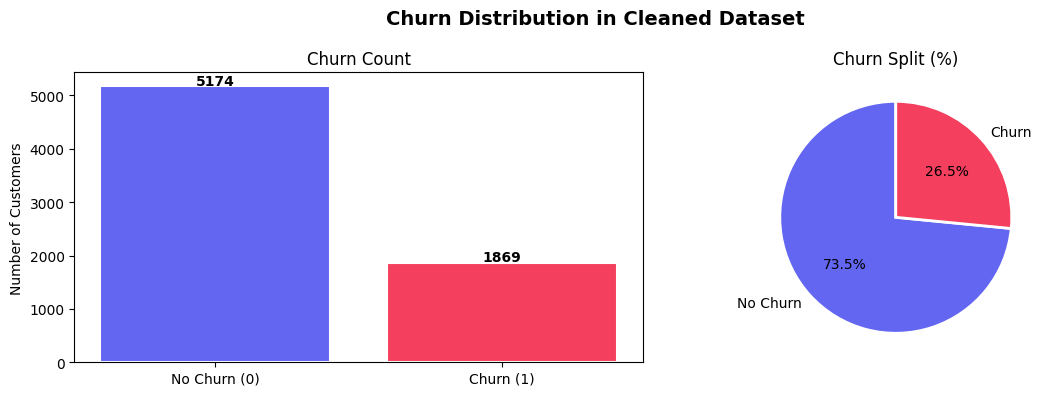

✅ Plot saved to data/churn_distribution.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Churn Distribution in Cleaned Dataset', fontsize=14, fontweight='bold')

colors = ['#6366f1', '#f43f5e']

# Bar chart
churn_counts = df['churn'].value_counts()
axes[0].bar(['No Churn (0)', 'Churn (1)'], churn_counts, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[1].set_title('Churn Split (%)')

plt.tight_layout()
plt.savefig('../data/churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot saved to data/churn_distribution.png')

## 1️⃣3️⃣ Export Cleaned Data

In [19]:
CLEANED_PATH = '../data/telco_churn_cleaned.csv'

df.to_csv(CLEANED_PATH, index=False)

print(f'✅ Cleaned dataset saved to: {CLEANED_PATH}')
print(f'   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

✅ Cleaned dataset saved to: ../data/telco_churn_cleaned.csv
   Shape: 7,043 rows × 21 columns


---

## 📋 Cleaning Summary

| Step | Action | Details |
|------|--------|---------|
| 1 | **Fix TotalCharges** | Converted `object` → `float`; 11 whitespace entries found |
| 2 | **Fill Missing Values** | 11 NaNs in `total_charges` filled with `0.0` (tenure = 0 customers) |
| 3 | **SeniorCitizen** | Mapped `0/1` → `No/Yes` for readability |
| 4 | **Simplify Services** | Replaced `'No phone service'` & `'No internet service'` → `'No'` |
| 5 | **Column Names** | Standardised to `snake_case` |
| 6 | **Encode Target** | `Churn`: `No → 0`, `Yes → 1` |
| 7 | **Duplicates** | 0 duplicates found |

**Output:** `data/telco_churn_cleaned.csv` — ready for EDA & modelling 🚀